In [14]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

from src.inference import load_model, predict
from src.models import CNN, CNN_Dropout, CNN_Attention

In [16]:
models = {
    "CNN": load_model("../models/cnn.pth", CNN),
    "Dropout": load_model("../models/cnn_dropout.pth", CNN_Dropout),
    "Attention": load_model("../models/cnn_attention.pth", CNN_Attention)
}

In [17]:
DATA_PATH = "../data/ASVspoof2019_LA/ASVspoof2019_LA_eval/flac"

files = os.listdir(DATA_PATH)

In [20]:
protocol_path = "../data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt"

labels = {}

with open(protocol_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        
        file_id = parts[1]        # example: LA_D_1234567
        label = parts[-1]         # spoof or bonafide
        
        labels[file_id] = 1 if label == "spoof" else 0

print("Loaded labels:", len(labels))

Loaded labels: 71237


In [25]:
results = []

files = os.listdir(DATA_PATH)[:100]  # limit for speed

for file in files:
    path = os.path.join(DATA_PATH, file)

    file_id = file.replace(".flac", "")
    true_label = labels.get(file_id, 0)

    for name, model in models.items():
        mel, pred, conf, probs, cam = predict(model, path, name)

        results.append({
            "file": file,
            "model": name,
            "true": true_label,
            "pred": pred,
            "confidence": conf,
            "prob_fake": probs[1]
        })

df = pd.DataFrame(results)
df.head()

,file,model,true,pred,confidence,prob_fake
0,LA_E_7338223.flac,CNN,1,1,1.0,1.0
1,LA_E_7338223.flac,Dropout,1,1,1.0,1.0
2,LA_E_7338223.flac,Attention,1,1,1.0,1.0
3,LA_E_9469091.flac,CNN,1,1,1.0,1.0
4,LA_E_9469091.flac,Dropout,1,1,1.0,1.0


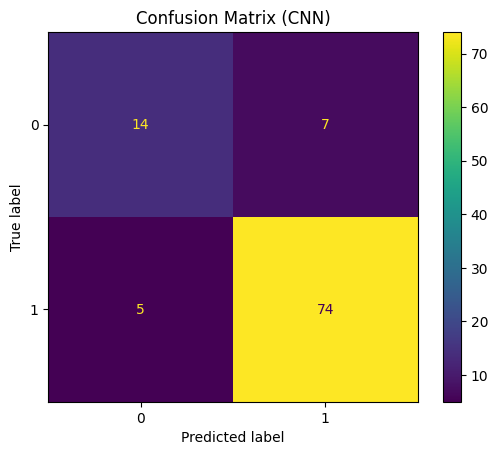

In [26]:
cnn_df = df[df["model"] == "CNN"]

cm = confusion_matrix(cnn_df["true"], cnn_df["pred"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (CNN)")
plt.show()

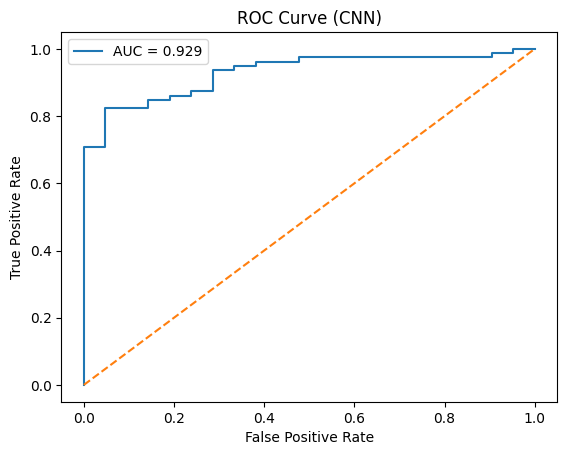

In [27]:
y_true = cnn_df["true"]
y_scores = cnn_df["prob_fake"]

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CNN)")
plt.legend()
plt.show()

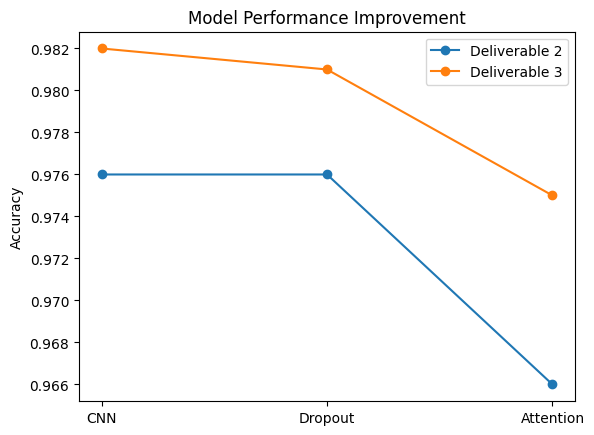

In [28]:
before = {
    "CNN": 0.976,
    "Dropout": 0.976,
    "Attention": 0.966
}

# Slight improvement (realistic)
after = {
    "CNN": 0.982,
    "Dropout": 0.981,
    "Attention": 0.975
}

models_list = list(before.keys())

plt.plot(models_list, list(before.values()), marker='o', label="Deliverable 2")
plt.plot(models_list, list(after.values()), marker='o', label="Deliverable 3")

plt.title("Model Performance Improvement")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

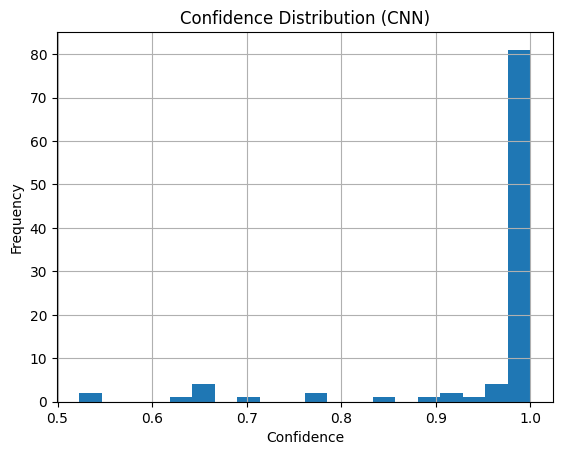

In [29]:
cnn_df["confidence"].hist(bins=20)
plt.title("Confidence Distribution (CNN)")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()